# Time and Type of regular days
- weekday vs weekend
- time blocks
- mean relative ranked demand

## data

In [1]:
#This gets us into the right directory from home, in order to run the import python script from Mat

#sys = system (module), gives information and control over python interpreter/terminal itself
import sys
sys.path.append("/home/565/pv3484/aus_substation_electricity")

#% is a magic command, special shortcut command that lets you control/interact with notebook environment (ie. gives control of terminal without writing full python code)
%cd aus_substation_electricity/

!pwd

/home/565/pv3484/aus_substation_electricity
/home/565/pv3484/aus_substation_electricity


In [2]:
#This section imports the substations that Mat put together

%run /home/565/pv3484/aus_substation_electricity/import_substation.py

processing nsw substations for ['ausgrid'] from None to None
ausgrid
following columns in demand are not in info index:
['MT_HU', 'SI_NO']
removing these columns from demand
number of substations in ausgrid substation info: 134
number of substations in ausgrid substation data: 132
following sites match selection criteria:
               energy_asset          Name  Area  Dwellings  Persons  Residential  Commercial  Industrial  Primary Production  Education  \
ID                                                                                                                                        
BLAKE         AG_BLAKEHURST    Blakehurst     7      10081    28521        0.850       0.005       0.021               0.000      0.022   
PUNCH          AG_PUNCHBOWL     Punchbowl     9      17514    50395        0.826       0.048       0.038               0.000      0.025   
MEADO         AG_MEADOWBANK    Meadowbank    15      22420    56948        0.825       0.023       0.015               0

In [3]:
demand.head()

,BLAKE,PUNCH,MEADO,MOSMA,RIVER,CA_CO,DU_HI,FI_DO,UMINA,CAMPS,...,LISAR,BEROW,HO_BA,SOMER,MORIS,WE_GO,WYONG,RUTHE,ROTHB,MUSWE
2004-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-01-01 00:30:00,11.77248,NaN,33.32921,26.86411,13.89570,23.07817,22.18987,15.14478,14.97165,28.97894,...,14.80155,15.49202,11.29188,6.80748,NaN,16.65575,12.23212,5.18215,NaN,9.24960
2004-01-01 01:00:00,10.40756,20.70845,30.79541,24.53589,11.52604,21.82337,20.55462,13.54961,17.09998,25.91148,...,16.72754,13.00451,11.47669,7.15043,NaN,18.55414,13.84397,4.32418,NaN,7.81060
2004-01-01 01:30:00,9.53552,19.09061,28.38565,22.76285,9.99050,20.53466,18.80529,12.44237,14.73313,23.68233,...,14.94422,11.04744,11.12555,6.22447,NaN,16.83484,12.07094,3.56669,NaN,6.56823
2004-01-01 02:00:00,8.39808,17.51083,26.50744,21.38383,8.39808,19.38160,17.60738,11.37266,11.99934,21.56750,...,13.16090,8.92574,11.36580,5.62432,NaN,15.15136,10.62028,3.10251,NaN,6.05148


Dropped 15 substations: ['KOGAR', 'TO_RY', 'BANKS', 'NE_CB', 'BA_NO', 'ADAMS', 'JESMO', 'CHARL', 'BROAD', 'PO_HI', 'MA_WE', 'GR_SQ', 'ARGEN', 'MORIS', 'ROTHB']


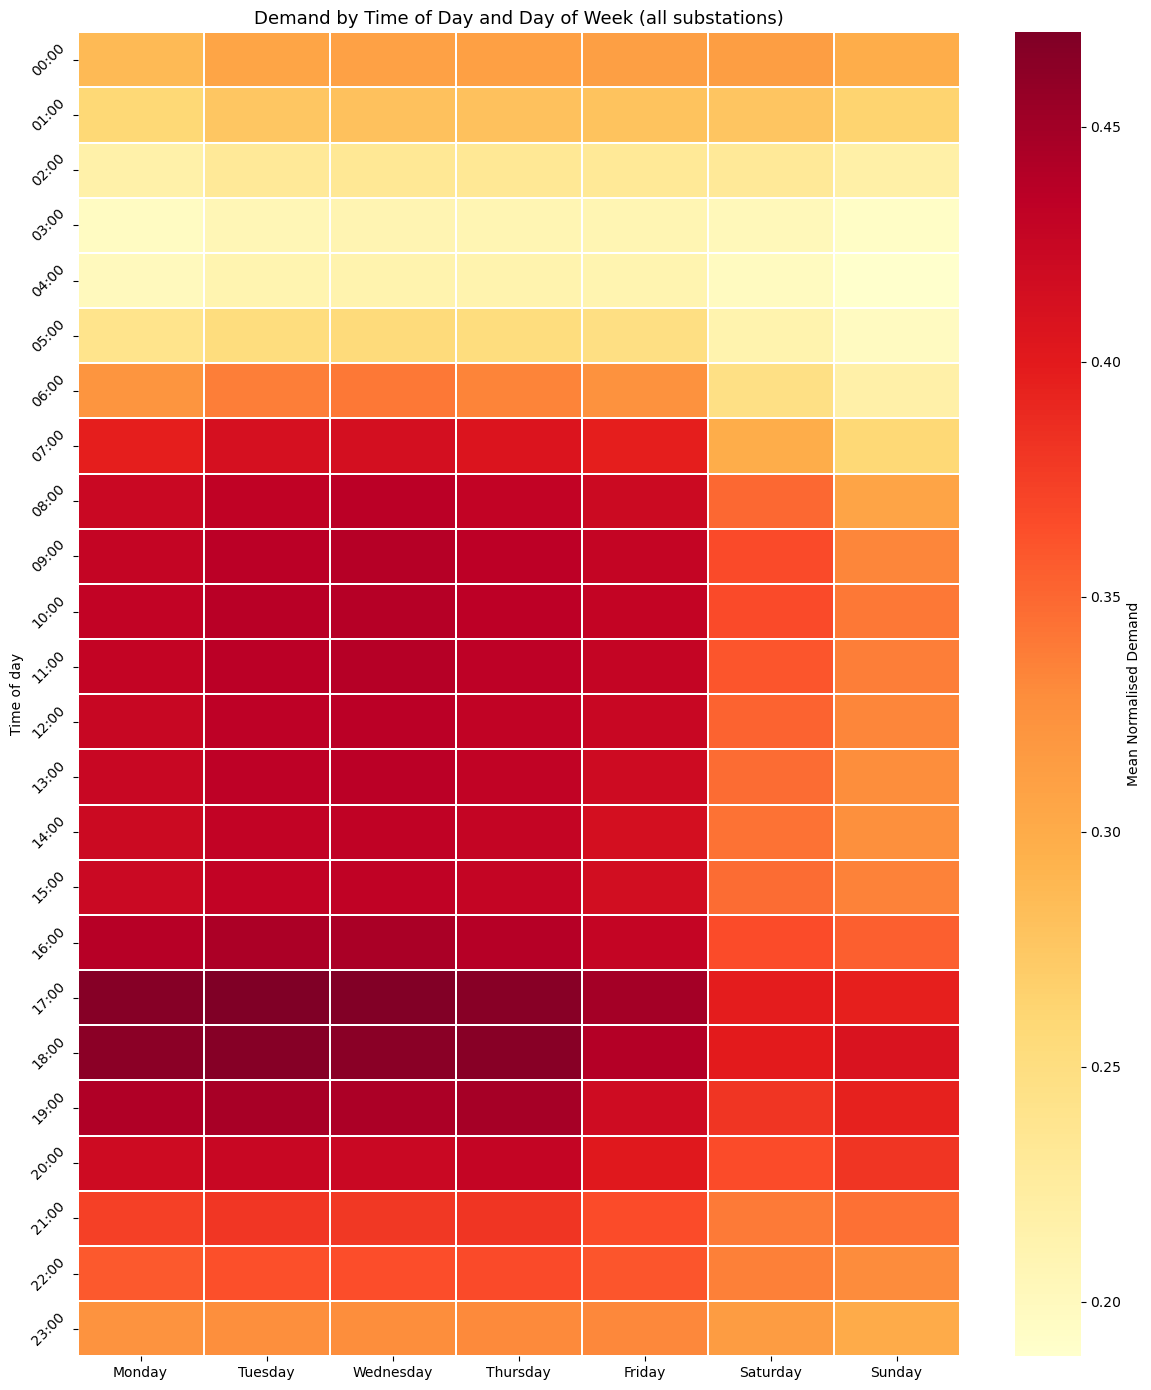

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Parse index
demand.index = pd.to_datetime(demand.index)

# 2. Drop columns with too many NaNs (>20% missing)
threshold = 0.2
demand_clean = demand.loc[:, demand.isnull().mean() < threshold]

# 3. Check what got dropped
dropped = demand.columns[demand.isnull().mean() >= threshold].tolist()
print(f"Dropped {len(dropped)} substations: {dropped}")

# 4. Derive time features
demand_clean = demand_clean.copy()
demand_clean['day_of_week'] = demand_clean.index.day_name()
demand_clean['time_block'] = demand_clean.index.strftime('%H:00')

# 5. Normalise each substation to 0–1
substation_cols = [c for c in demand_clean.columns if c not in ['day_of_week', 'time_block']]
demand_norm = demand_clean[substation_cols].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
demand_norm['day_of_week'] = demand_clean['day_of_week']
demand_norm['time_block'] = demand_clean['time_block']

# 6. Pivot
pivot = (
    demand_norm.groupby(['day_of_week', 'time_block'])[substation_cols]
    .mean()
    .mean(axis=1)
    .unstack(level=0)
)

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot[day_order]
pivot = pivot.reindex(sorted(pivot.index))

# 7. Plot
fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Mean Normalised Demand'},
    linewidths=0.3,
    linecolor='white'
)
ax.set_title('Demand by Time of Day and Day of Week (all substations)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Time of day')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

In [5]:
print(demand_clean['day_of_week'].value_counts())

day_of_week
Sunday       29517
Wednesday    29441
Tuesday      29415
Saturday     29399
Thursday     29358
Friday       29304
Monday       29221
Name: count, dtype: int64


## Isolating from 7am - 9pm to see finer scale changes

Dropped 16 substations: ['KOGAR', 'TO_RY', 'BANKS', 'NE_CB', 'BA_NO', 'ADAMS', 'JESMO', 'CHARL', 'BROAD', 'PO_HI', 'MA_WE', 'GR_SQ', 'ARGEN', 'MORIS', 'RUTHE', 'ROTHB']


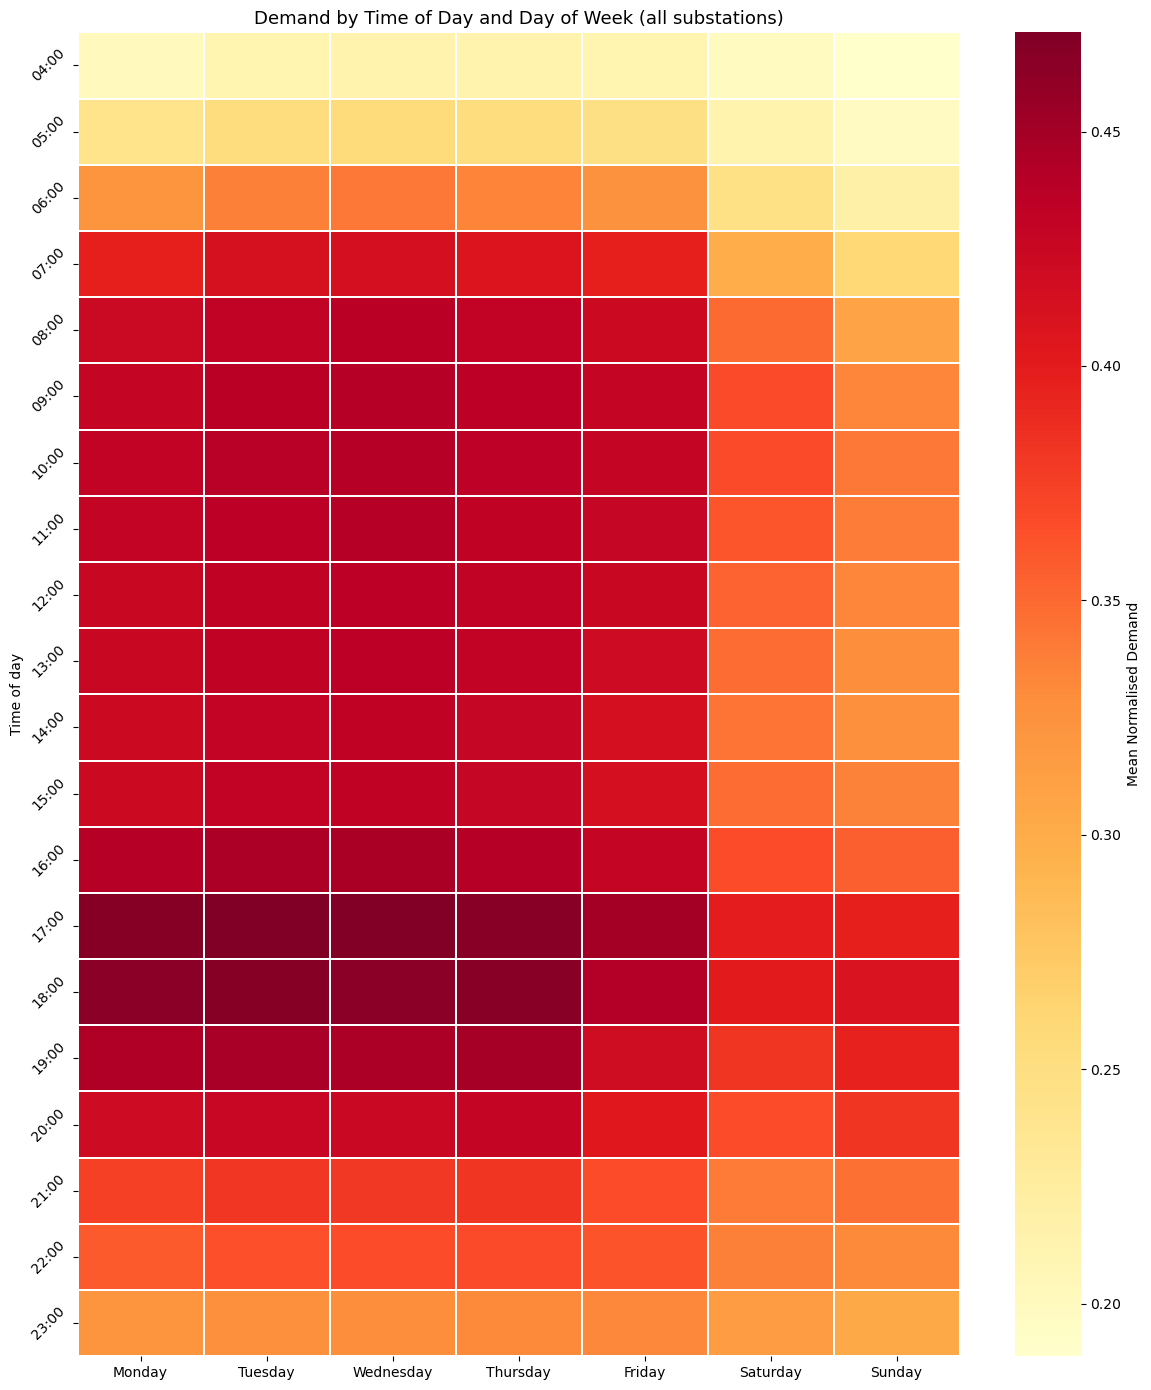

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Parse index
demand.index = pd.to_datetime(demand.index)

# 2. Drop columns with too many NaNs (>20% missing)
threshold = 0.1
demand_clean = demand.loc[:, demand.isnull().mean() < threshold]

# 3. Check what got dropped
dropped = demand.columns[demand.isnull().mean() >= threshold].tolist()
print(f"Dropped {len(dropped)} substations: {dropped}")

# 4. Derive time features
demand_clean = demand_clean.copy()
demand_clean['day_of_week'] = demand_clean.index.day_name()
demand_clean['time_block'] = demand_clean.index.strftime('%H:00')

# 5. Normalise each substation to 0–1
substation_cols = [c for c in demand_clean.columns if c not in ['day_of_week', 'time_block']]
demand_norm = demand_clean[substation_cols].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
demand_norm['day_of_week'] = demand_clean['day_of_week']
demand_norm['time_block'] = demand_clean['time_block']

# 6. Pivot
pivot = (
    demand_norm.groupby(['day_of_week', 'time_block'])[substation_cols]
    .mean()
    .mean(axis=1)
    .unstack(level=0)
)

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot[day_order]
pivot = pivot.reindex(sorted(pivot.index))

# 6.5 Pivot_peak for 7am - 9pm
peak_hours = [f'{h:02d}:00' for h in range(4, 24)]
pivot_peak = pivot.reindex(peak_hours)

# 7. Plot
fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(
    pivot_peak,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Mean Normalised Demand'},
    linewidths=0.3,
    linecolor='white'
)
ax.set_title('Demand by Time of Day and Day of Week (all substations)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Time of day')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

In [7]:
info.head()

,energy_asset,Name,Area,Dwellings,Persons,Residential,Commercial,Industrial,Primary Production,Education,Hospital/Medical,Transport,Parkland,Water,Other
BLAKE,AG_BLAKEHURST,Blakehurst,7,10081,28521,0.850,0.005,0.021,0.0,0.022,0.001,0.000,0.102,0.0,0.0
PUNCH,AG_PUNCHBOWL,Punchbowl,9,17514,50395,0.826,0.048,0.038,0.0,0.025,0.002,0.001,0.061,0.0,0.0
MEADO,AG_MEADOWBANK,Meadowbank,15,22420,56948,0.825,0.023,0.015,0.0,0.036,0.014,0.006,0.082,0.0,0.0
MOSMA,AG_MOSMAN,Mosman,11,25967,52831,0.817,0.046,0.001,0.0,0.013,0.001,0.000,0.123,0.0,0.0
RIVER,AG_RIVERWOOD,Riverwood,10,12528,34547,0.813,0.018,0.042,0.0,0.035,0.002,0.001,0.089,0.0,0.0


## Isolating heatmap for substations with residential fraction >0.75

In [8]:
# Get substations with residential fraction > 0.75
residential_subs = info[info['Residential'] > 0.75].index.tolist()

# Keep only those that survived the NaN threshold drop
residential_subs = [s for s in residential_subs if s in substation_cols]

print(f"{len(residential_subs)} substations with residential fraction > 0.75")

13 substations with residential fraction > 0.75


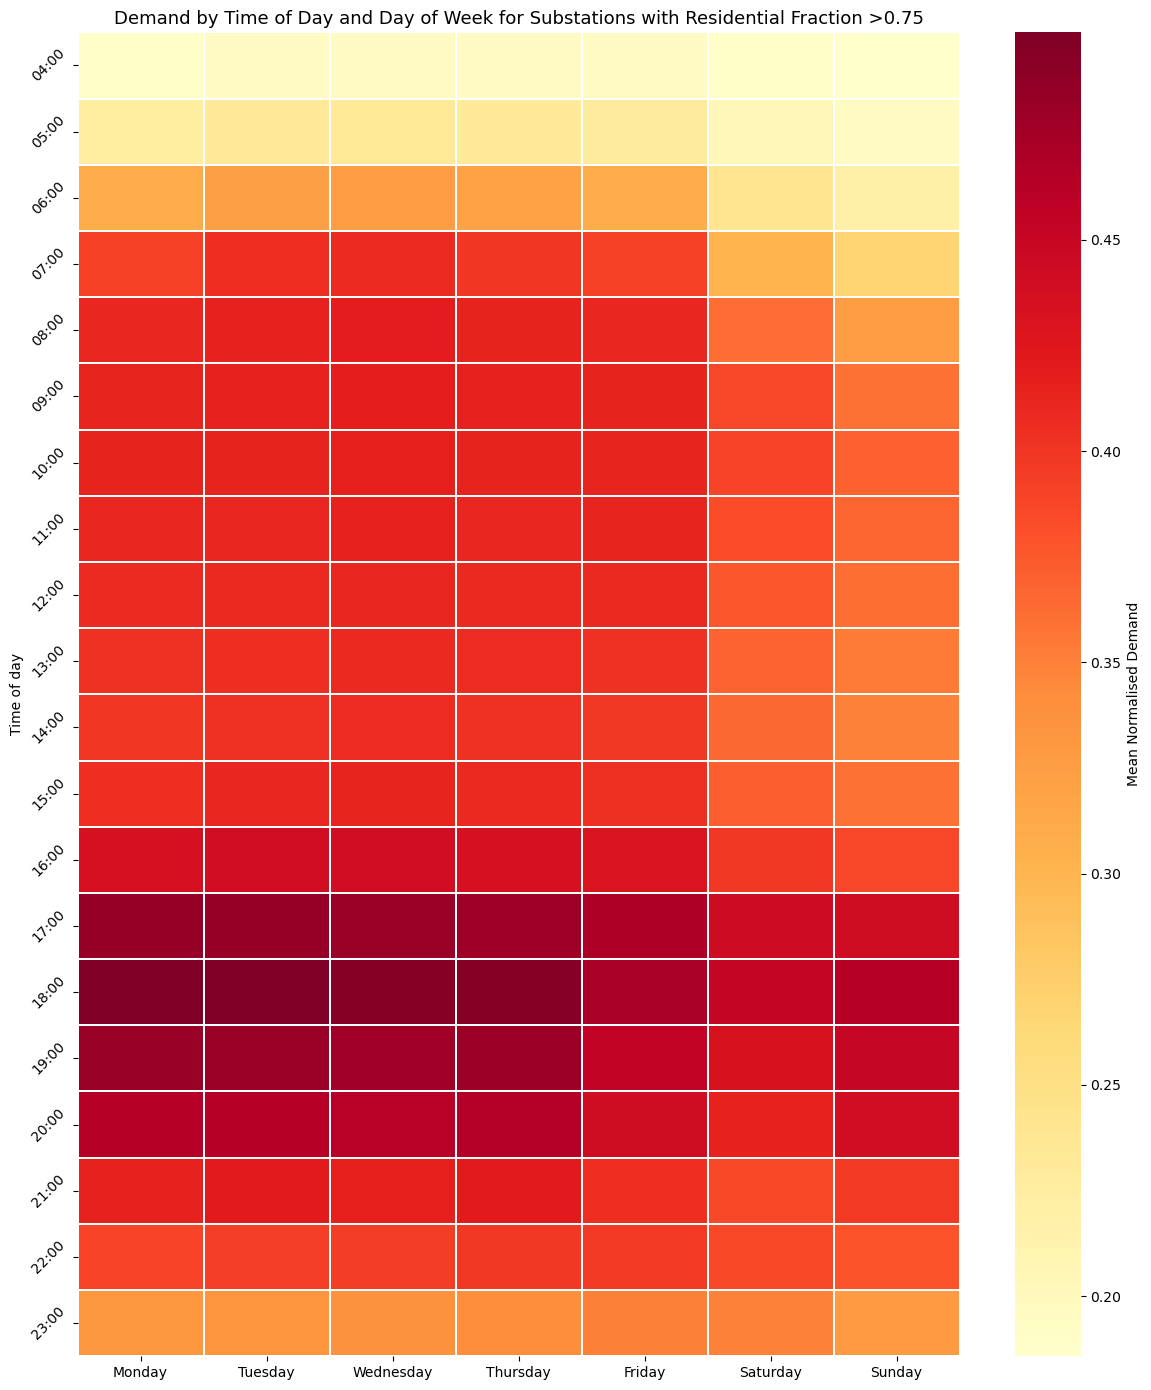

In [9]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot_res = (
    demand_norm.groupby(['day_of_week', 'time_block'])[residential_subs]
    .mean()
    .mean(axis=1)
    .unstack(level=0)
)
peak_hours = [f'{h:02d}:00' for h in range(4, 24)]
pivot_res = pivot_res.reindex(peak_hours)[day_order]

# 7. Plot
fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(
    pivot_res,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Mean Normalised Demand'},
    linewidths=0.3,
    linecolor='white'
)
ax.set_title('Demand by Time of Day and Day of Week for Substations with Residential Fraction >0.75', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Time of day')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

# Seeing which substations are making a bigger influence on the demand in the morning peak (higher morning peak in all substations vs res >0.75)

In [10]:
# Define morning hours
morning = [f'{h:02d}:{m}' for h in range(7, 10) for m in ('00', '30')]

# Non-residential substations (those excluded from residential filter)
non_res_subs = [s for s in substation_cols if s not in residential_subs]

# Mean normalised demand during morning for each substation
morning_mask = demand_norm['time_block'].isin(morning)

# adding weekday filter
weekdays = ['Monday','Tuesday','Wednesday','Thursday','Friday']
morning_mask = demand_norm['time_block'].isin(morning) & demand_norm['day_of_week'].isin(weekdays)

morning_demand = (
    demand_norm[morning_mask]
    .groupby('day_of_week')[substation_cols]
    .mean()
    .mean()
    .sort_values(ascending=False)
)

# Split into res vs non-res
morning_res = morning_demand[morning_demand.index.isin(residential_subs)]
morning_non_res = morning_demand[morning_demand.index.isin(non_res_subs)]

print("Top 10 morning peak substations (residential):")
print(morning_res.head(10))
print("\nTop 10 morning peak substations (non-residential):")
print(morning_non_res.head(10))

Top 10 morning peak substations (residential):
CA_CO    0.548753
HU_HI    0.484763
CHATS    0.479114
DU_HI    0.467976
CAMPS    0.438111
FI_DO    0.405678
PUNCH    0.379035
BLAKE    0.378573
MOSMA    0.375992
MEADO    0.356623
dtype: float64

Top 10 morning peak substations (non-residential):
MILPE    0.613777
SOMER    0.610060
BE_HI    0.599940
MAROU    0.598885
ST_PE    0.593285
LEIGH    0.592627
BROOK    0.592442
HORNS    0.525710
HO_BA    0.520872
GO_HI    0.520365
dtype: float64


In [11]:
info.loc['KIRRA']

energy_asset          AG_KIRRAWEE
Name                     Kirrawee
Area                           16
Dwellings                   13004
Persons                     32445
Residential                 0.563
Commercial                  0.007
Industrial                   0.05
Primary Production            0.0
Education                   0.036
Hospital/Medical              0.0
Transport                     0.0
Parkland                    0.344
Water                         0.0
Other                         0.0
Name: KIRRA, dtype: object

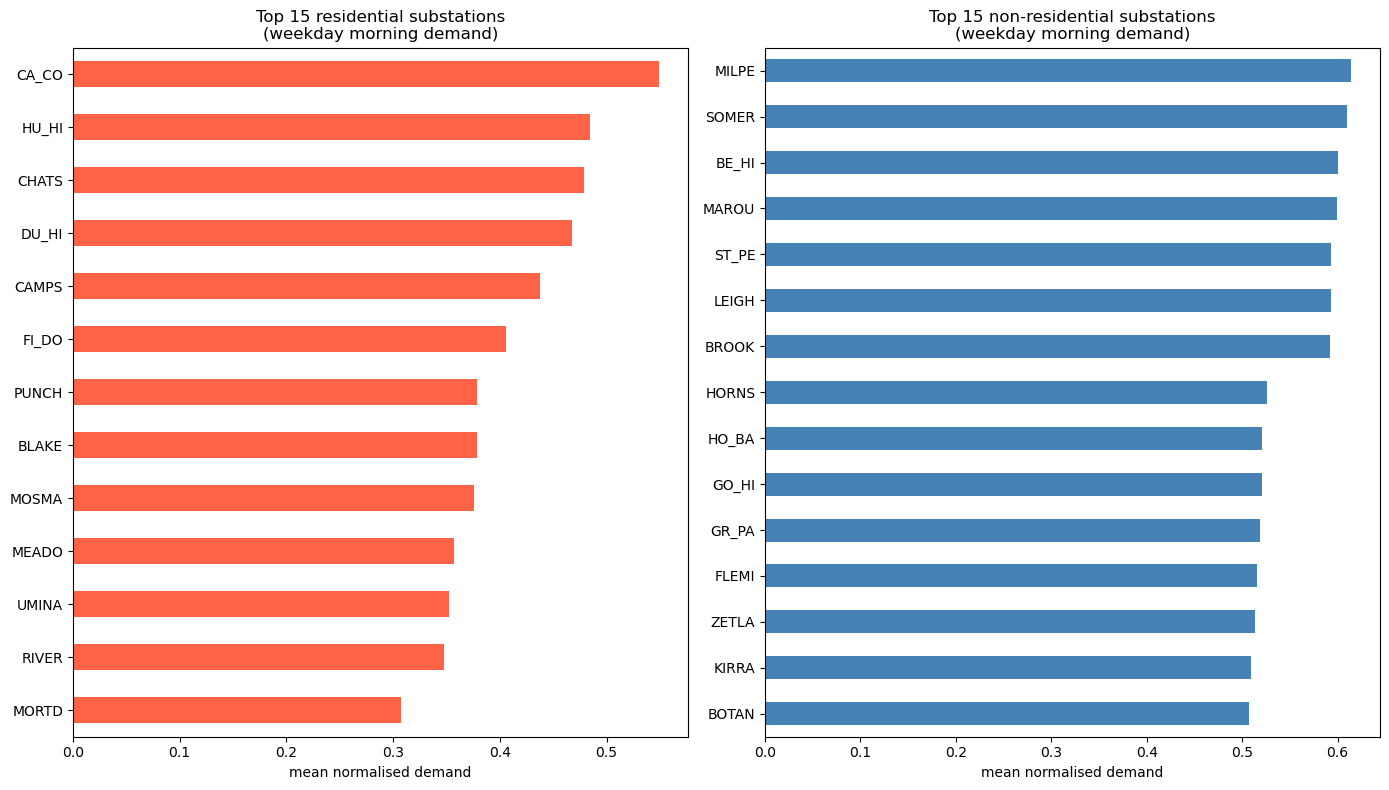

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

morning_res.head(15).plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('Top 15 residential substations\n(weekday morning demand)')
axes[0].set_xlabel('mean normalised demand')
axes[0].invert_yaxis()

morning_non_res.head(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 non-residential substations\n(weekday morning demand)')
axes[1].set_xlabel('mean normalised demand')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [13]:
info.loc[morning_non_res.head(15).index, ['Name','Commercial', 'Industrial', 'Education','Residential','Persons']]

,Name,Commercial,Industrial,Education,Residential,Persons
MILPE,Milperra,0.025,0.189,0.042,0.461,25752
SOMER,Somersby,0.009,0.110,0.001,0.099,6666
BE_HI,Beacon Hill,0.086,0.001,0.046,0.562,15037
MAROU,Maroubra,0.019,0.223,0.024,0.582,27992
ST_PE,St. Peters,0.071,0.222,0.025,0.544,36286
LEIGH,Leightonfield,0.003,0.275,0.040,0.489,11717
BROOK,Brookvale,0.098,0.188,0.034,0.538,20845
HORNS,Hornsby,0.021,0.036,0.046,0.731,52277
HO_BA,Homebush Bay,0.373,0.155,0.002,0.126,17591
GO_HI,Gore Hill,0.046,0.234,0.024,0.521,16837


In [14]:
info.loc[morning_res.head(15).index, ['Name','Commercial', 'Industrial', 'Education','Residential','Persons']]

,Name,Commercial,Industrial,Education,Residential,Persons
CA_CO,Castle Cove,0.033,0.031,0.017,0.807,30714
HU_HI,Hunters Hill,0.020,0.002,0.043,0.782,23915
CHATS,Chatswood,0.020,0.052,0.049,0.766,51581
DU_HI,Dulwich Hill,0.023,0.007,0.036,0.799,43563
CAMPS,Campsie,0.025,0.057,0.016,0.789,68810
FI_DO,Five Dock,0.044,0.020,0.032,0.798,38795
PUNCH,Punchbowl,0.048,0.038,0.025,0.826,50395
BLAKE,Blakehurst,0.005,0.021,0.022,0.850,28521
MOSMA,Mosman,0.046,0.001,0.013,0.817,52831
MEADO,Meadowbank,0.023,0.015,0.036,0.825,56948


In [15]:
indus_max = max(info['Industrial'])
print(indus_max)

0.593


In [16]:
info[info['Industrial'] == indus_max]

,energy_asset,Name,Area,Dwellings,Persons,Residential,Commercial,Industrial,Primary Production,Education,Hospital/Medical,Transport,Parkland,Water,Other
AUBUR,AG_AUBURN,Auburn,2,1957,5710,0.298,0.003,0.593,0.0,0.024,0.0,0.082,0.0,0.0,0.0


### Evening

In [17]:
# Define evening hours
evening = [f'{h:02d}:{m}' for h in range(16, 21) for m in ('00', '30')]

# Non-residential substations (those excluded from residential filter)
non_res_subs = [s for s in substation_cols if s not in residential_subs]

# Mean normalised demand during morning for each substation
evening_mask = demand_norm['time_block'].isin(evening)

# adding weekday filter
weekdays = ['Monday','Tuesday','Wednesday','Thursday','Friday']
evening_mask = demand_norm['time_block'].isin(evening) & demand_norm['day_of_week'].isin(weekdays)

evening_demand = (
    demand_norm[evening_mask]
    .groupby('day_of_week')[substation_cols]
    .mean()
    .mean()
    .sort_values(ascending=False)
)

# Split into res vs non-res
evening_res = evening_demand[evening_demand.index.isin(residential_subs)]
evening_non_res = evening_demand[evening_demand.index.isin(non_res_subs)]

print("Top 10 Evening peak substations (residential):")
print(evening_res.head(10))
print("\nTop 10 Evening peak substations (non-residential):")
print(evening_non_res.head(10))

Top 10 Evening peak substations (residential):
CA_CO    0.555828
DU_HI    0.532735
CHATS    0.510537
HU_HI    0.504991
CAMPS    0.504481
FI_DO    0.495123
UMINA    0.452412
MOSMA    0.447593
BLAKE    0.437901
RIVER    0.434502
dtype: float64

Top 10 Evening peak substations (non-residential):
MAROU    0.616530
ST_PE    0.566336
BE_HI    0.560596
HORNS    0.559573
LEIGH    0.554725
KIRRA    0.540950
DE_WH    0.528895
LISAR    0.527370
GR_PA    0.523230
BROOK    0.514925
dtype: float64


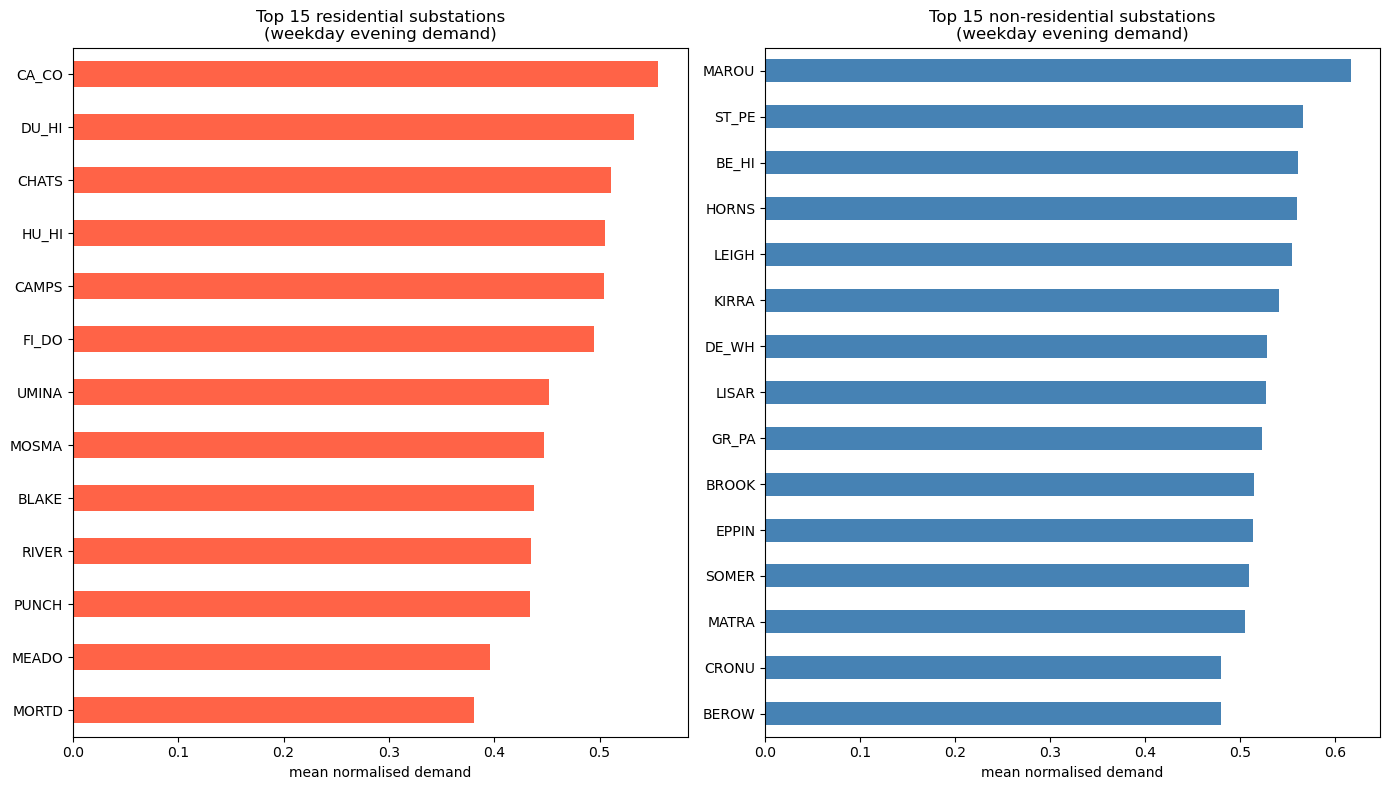

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

evening_res.head(15).plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('Top 15 residential substations\n(weekday evening demand)')
axes[0].set_xlabel('mean normalised demand')
axes[0].invert_yaxis()

evening_non_res.head(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 non-residential substations\n(weekday evening demand)')
axes[1].set_xlabel('mean normalised demand')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [19]:
# weekend evening

# Define evening hours
evening = [f'{h:02d}:{m}' for h in range(16, 21) for m in ('00', '30')]

# Non-residential substations (those excluded from residential filter)
non_res_subs = [s for s in substation_cols if s not in residential_subs]

# Mean normalised demand during morning for each substation
evening_mask = demand_norm['time_block'].isin(evening)

# adding weekday filter
weekends = ['Saturday', 'Sunday']
evening_mask = demand_norm['time_block'].isin(evening) & demand_norm['day_of_week'].isin(weekends)

evening_demand = (
    demand_norm[evening_mask]
    .groupby('day_of_week')[substation_cols]
    .mean()
    .mean()
    .sort_values(ascending=False)
)

# Split into res vs non-res
evening_res = evening_demand[evening_demand.index.isin(residential_subs)]
evening_non_res = evening_demand[evening_demand.index.isin(non_res_subs)]

print("Top 10 Evening peak substations (residential):")
print(evening_res.head(10))
print("\nTop 10 Evening peak substations (non-residential):")
print(evening_non_res.head(10))

Top 10 Evening peak substations (residential):
DU_HI    0.504889
CA_CO    0.481389
CAMPS    0.457710
FI_DO    0.455017
UMINA    0.454590
CHATS    0.453795
HU_HI    0.451035
MOSMA    0.430497
BLAKE    0.411751
RIVER    0.398212
dtype: float64

Top 10 Evening peak substations (non-residential):
MAROU    0.536011
HORNS    0.507786
DE_WH    0.489893
KIRRA    0.485769
ST_PE    0.467943
SWANS    0.465860
CRONU    0.464848
BEROW    0.459033
NORAV    0.452596
ARNCL    0.451812
dtype: float64


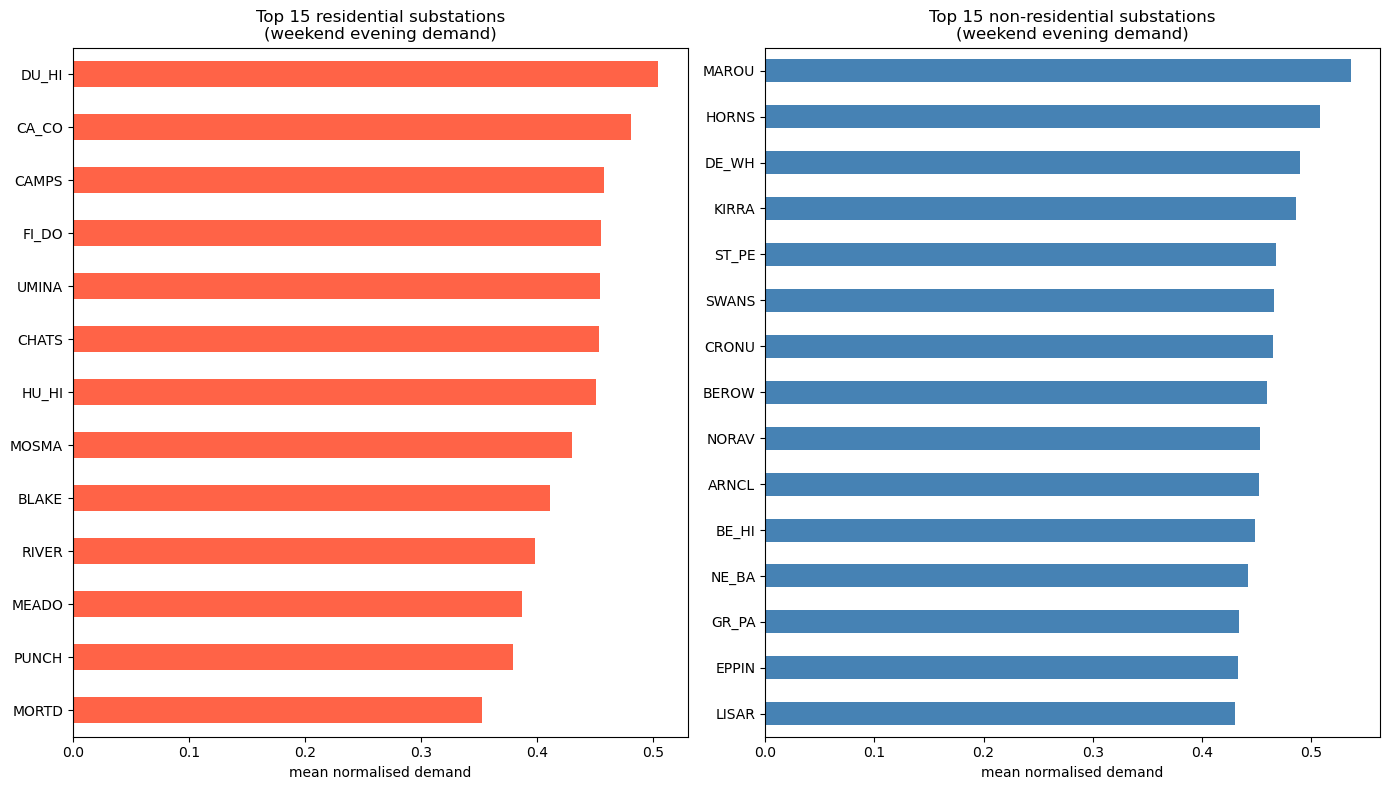

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
evening_res.head(15).plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('Top 15 residential substations\n(weekend evening demand)')
axes[0].set_xlabel('mean normalised demand')
axes[0].invert_yaxis()

evening_non_res.head(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 non-residential substations\n(weekend evening demand)')
axes[1].set_xlabel('mean normalised demand')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Heat map plotting but with seasons

In [21]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

demand_clean['season'] = demand_clean.index.month.map(get_season)
demand_norm['season'] = demand_clean['season']

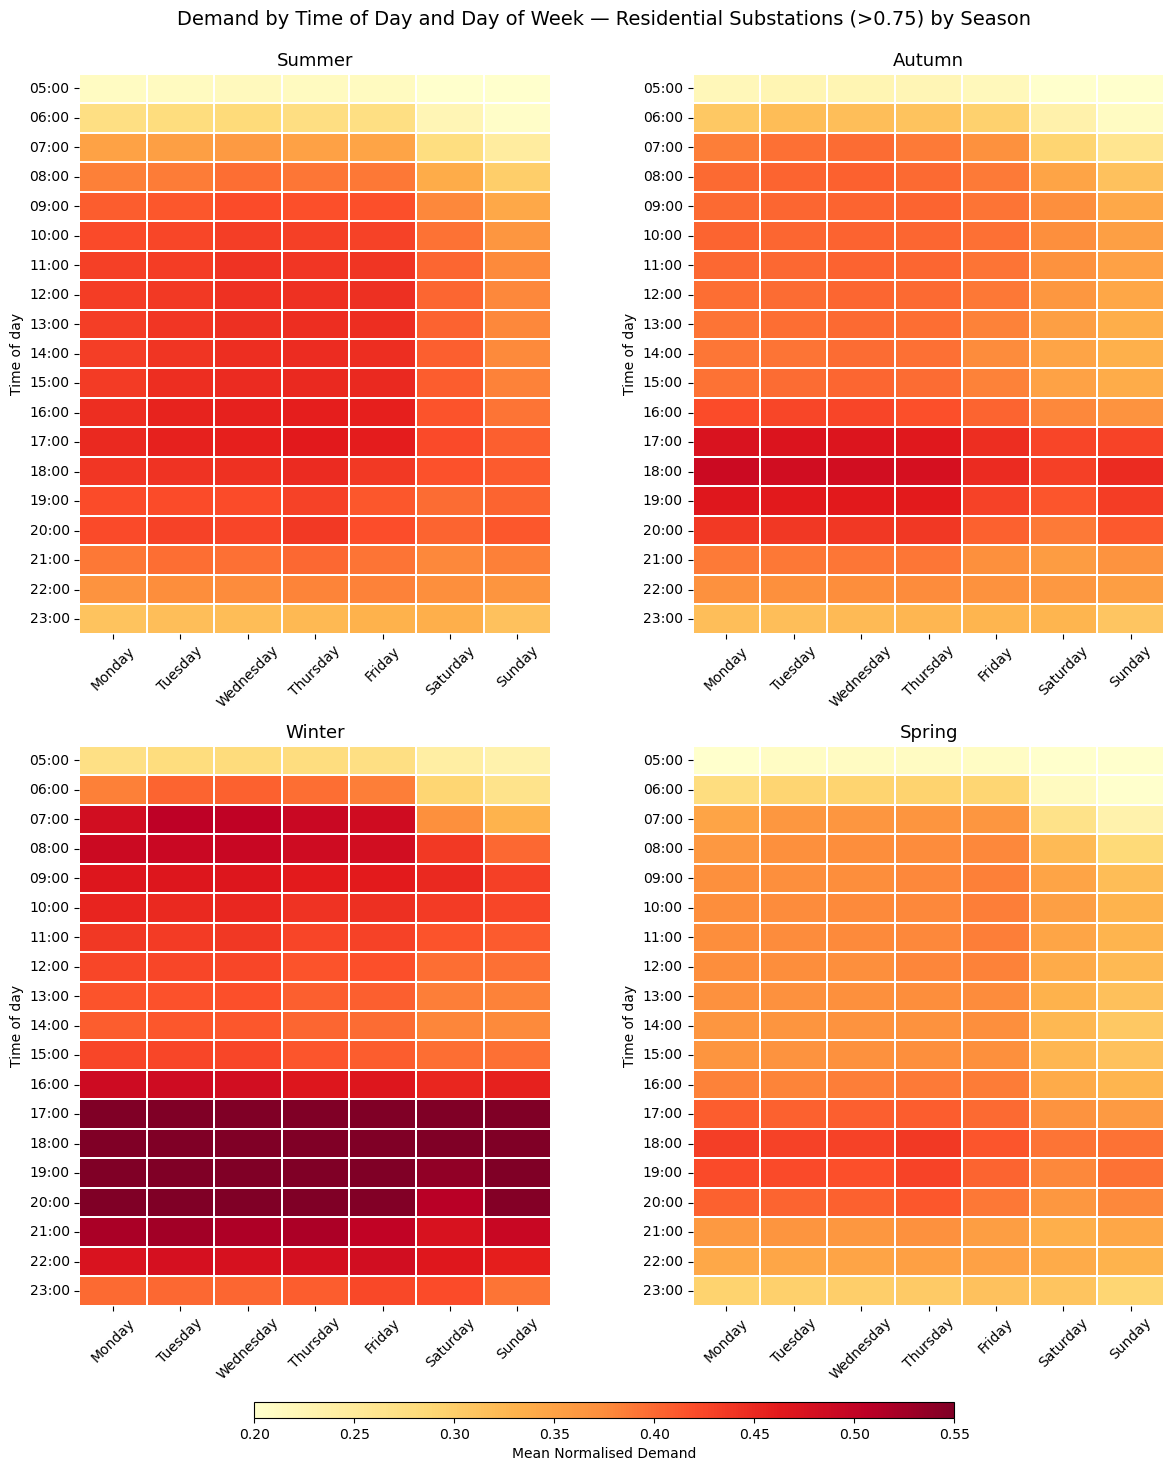

In [22]:
seasons = ['Summer', 'Autumn', 'Winter', 'Spring']
fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

peak_hours = [f'{h:02d}:00' for h in range(5, 24)]

for i, season in enumerate(seasons):
    season_mask = demand_norm['season'] == season
    
    pivot_season = (
        demand_norm[season_mask]
        .groupby(['day_of_week', 'time_block'])[residential_subs]
        .mean()
        .mean(axis=1)
        .unstack(level=0)
    )
    
    pivot_season = pivot_season.reindex(peak_hours)[day_order]
    
    sns.heatmap(
        pivot_season,
        cmap='YlOrRd',
        ax=axes[i],
        cbar=False,
        linewidths=0.3,
        linecolor='white',
        vmin=0.2,
        vmax=0.55
    )
    axes[i].set_title(f'{season}', fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Time of day')
    axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0, ha='right')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='center')
    axes[i].tick_params(axis='y', labelsize=10)

# Universal colourbar
import matplotlib.cm as cm
import matplotlib.colors as mcolors
sm = cm.ScalarMappable(cmap='YlOrRd', norm=mcolors.Normalize(vmin=0.2, vmax=0.55))
sm.set_array([])
cbar_ax = fig.add_axes([0.25, 0.04, 0.5, 0.01])  # [left, bottom, width, height]
fig.colorbar(sm, cax=cbar_ax, label='Mean Normalised Demand', orientation='horizontal')

fig.suptitle('Demand by Time of Day and Day of Week — Residential Substations (>0.75) by Season', 
             fontsize=14, y=0.92)
plt.subplots_adjust(hspace=0.2, wspace=0.3)
# plt.tight_layout()
plt.show()

# Heatmap differences
- red = all-substation demand is higher than residentia
- blue = residential is higher than the network average

## overall

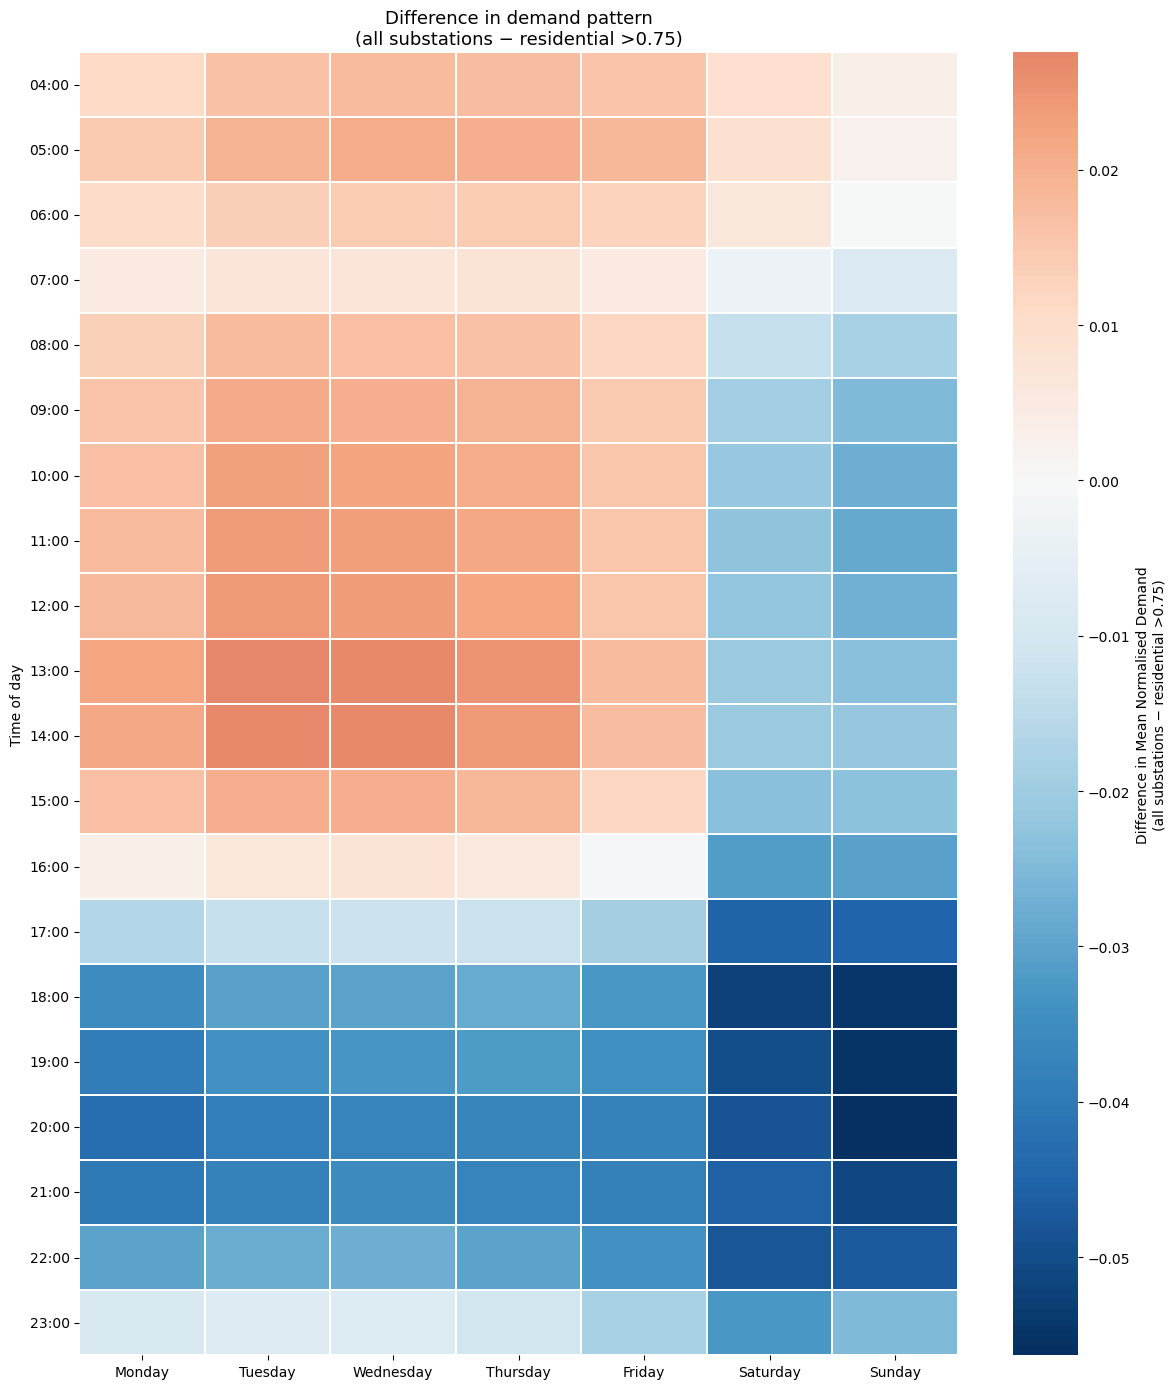

In [23]:
pivot_diff = pivot_peak - pivot_res

fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(
    pivot_diff,
    cmap='RdBu_r',
    ax=ax,
    center=0,
    cbar_kws={'label': 'Difference in Mean Normalised Demand\n(all substations − residential >0.75)'},
    linewidths=0.3,
    linecolor='white'
)
ax.set_title('Difference in demand pattern\n(all substations − residential >0.75)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Time of day')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

## Seasonal

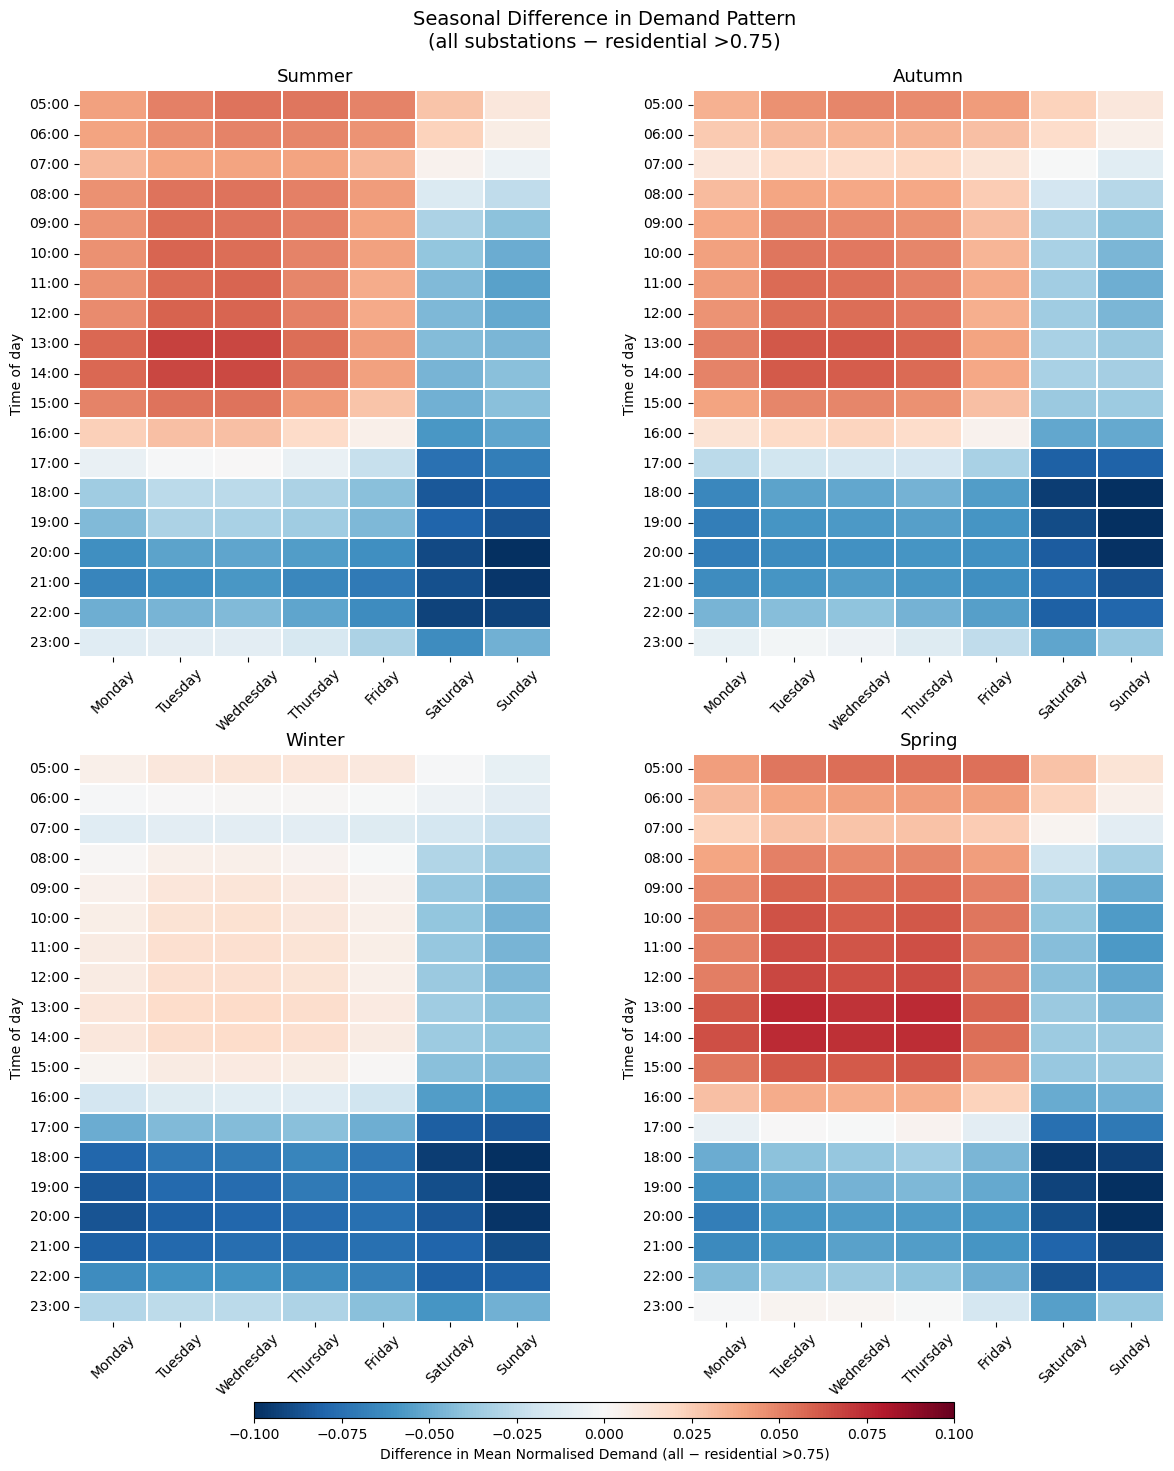

In [24]:
seasons = ['Summer', 'Autumn', 'Winter', 'Spring']
fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

peak_hours = [f'{h:02d}:00' for h in range(5, 24)]

for i, season in enumerate(seasons):
    season_mask = demand_norm['season'] == season

    pivot_all_season = (
        demand_norm[season_mask]
        .groupby(['day_of_week', 'time_block'])[substation_cols]
        .mean()
        .mean(axis=1)
        .unstack(level=0)
    )

    pivot_res_season = (
        demand_norm[season_mask]
        .groupby(['day_of_week', 'time_block'])[residential_subs]
        .mean()
        .mean(axis=1)
        .unstack(level=0)
    )

    pivot_all_season = pivot_all_season.reindex(peak_hours)[day_order]
    pivot_res_season = pivot_res_season.reindex(peak_hours)[day_order]

    pivot_diff_season = pivot_all_season - pivot_res_season

    sns.heatmap(
        pivot_diff_season,
        cmap='RdBu_r',
        ax=axes[i],
        center=0,
        cbar=False,
        linewidths=0.3,
        linecolor='white'
    )
    axes[i].set_title(f'{season}', fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Time of day')
    axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0, ha='right')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='center')
    axes[i].tick_params(axis='y', labelsize=10)

import matplotlib.cm as cm
import matplotlib.colors as mcolors
sm = cm.ScalarMappable(cmap='RdBu_r', norm=mcolors.TwoSlopeNorm(vmin=-0.1, vcenter=0, vmax=0.1))
sm.set_array([])
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.01])  # [left, bottom, width, height]
fig.colorbar(sm, cax=cbar_ax, label='Difference in Mean Normalised Demand (all − residential >0.75)', orientation='horizontal')

fig.suptitle('Seasonal Difference in Demand Pattern\n(all substations − residential >0.75)', fontsize=14, y=0.93)
plt.subplots_adjust(hspace=0.17, wspace=0.3)
plt.show()

In [25]:
info.loc[residential_subs, ['Name', 'Area', 'Residential']].sort_values('Residential', ascending=False)

,Name,Area,Residential
BLAKE,Blakehurst,7,0.850
PUNCH,Punchbowl,9,0.826
MEADO,Meadowbank,15,0.825
MOSMA,Mosman,11,0.817
RIVER,Riverwood,10,0.813
CA_CO,Castle Cove,10,0.807
DU_HI,Dulwich Hill,9,0.799
FI_DO,Five Dock,8,0.798
UMINA,Umina,16,0.790
CAMPS,Campsie,16,0.789


## < 0.75 res - > 0.75 res heatmap

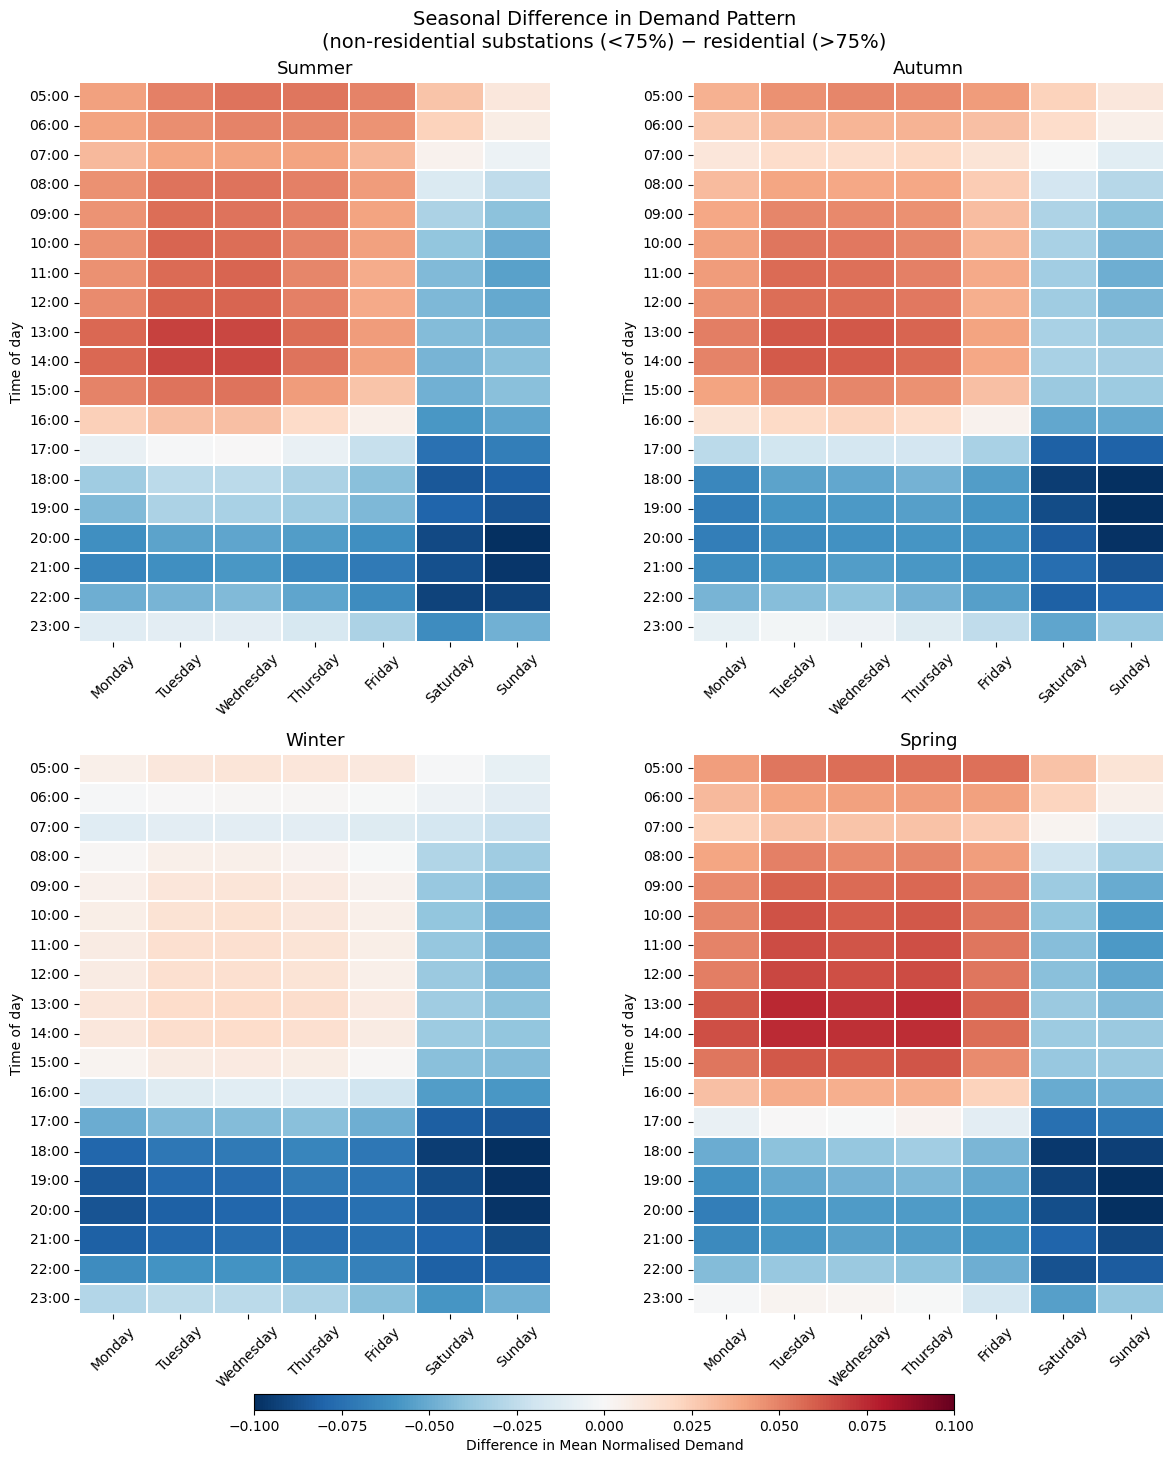

In [31]:
seasons = ['Summer', 'Autumn', 'Winter', 'Spring']
fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

peak_hours = [f'{h:02d}:00' for h in range(5, 24)]

for i, season in enumerate(seasons):
    season_mask = demand_norm['season'] == season

    pivot_non_res_season = (
        demand_norm[season_mask]
        .groupby(['day_of_week', 'time_block'])[non_res_subs]
        .mean()
        .mean(axis=1)
        .unstack(level=0)
    )

    pivot_res_season = (
        demand_norm[season_mask]
        .groupby(['day_of_week', 'time_block'])[residential_subs]
        .mean()
        .mean(axis=1)
        .unstack(level=0)
    )

    pivot_non_res_season = pivot_non_res_season.reindex(peak_hours)[day_order]
    pivot_res_season = pivot_res_season.reindex(peak_hours)[day_order]

    pivot_diff_season = pivot_non_res_season - pivot_res_season

    sns.heatmap(
        pivot_diff_season,
        cmap='RdBu_r',
        ax=axes[i],
        center=0,
        cbar=False,
        linewidths=0.3,
        linecolor='white'
    )
    axes[i].set_title(f'{season}', fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Time of day')
    axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0, ha='right')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='center')
    axes[i].tick_params(axis='y', labelsize=10)

import matplotlib.cm as cm
import matplotlib.colors as mcolors
sm = cm.ScalarMappable(cmap='RdBu_r', norm=mcolors.TwoSlopeNorm(vmin=-0.1, vcenter=0, vmax=0.1))
sm.set_array([])
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.01])
fig.colorbar(sm, cax=cbar_ax, label='Difference in Mean Normalised Demand', orientation='horizontal')

fig.suptitle('Seasonal Difference in Demand Pattern\n(non-residential substations (<75%) − residential (>75%)', fontsize=14, y=0.925)
plt.subplots_adjust(hspace=0.2, wspace=0.3)
plt.show()